In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import RMSprop

In [8]:
img = image.load_img("Base data/train/normal_tooth/1.jpg")

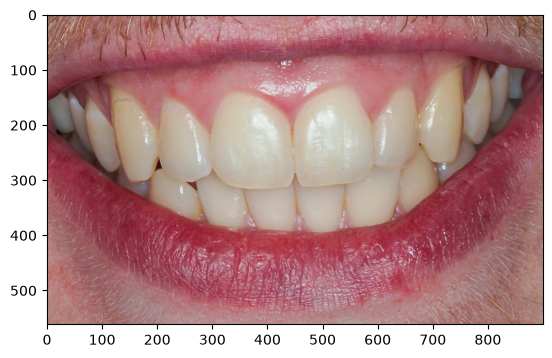

In [9]:
plt.imshow(img)

In [10]:
cv2.imread("Base data/train/normal_tooth/1.jpg").shape

(562, 900, 3)

In [21]:
train_gen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

validation_gen = ImageDataGenerator(rescale=1/255)

train_dataset = train_gen.flow_from_directory(
    "Base data/train",
    target_size=(224, 224),
    batch_size=8,
    class_mode="binary"
)

validation_dataset = validation_gen.flow_from_directory(
    "Base data/validation",
    target_size=(224, 224),
    batch_size=8,
    class_mode="binary"
)

print(train_dataset.class_indices)

Found 11 images belonging to 2 classes.
Found 11 images belonging to 2 classes.
{'cavity_tooth': 0, 'normal_tooth': 1}


In [14]:
train_dataset = train.flow_from_directory("Base data/train", 
                                          target_size = (224,224), 
                                          batch_size = 3,
                                          class_mode='binary')
validation_dataset = train.flow_from_directory("Base data/validation", 
                                          target_size = (224,224), 
                                          batch_size = 3,
                                          class_mode='binary')

NameError: name 'train' is not defined

In [15]:
train_dataset.class_indices

{'cavity_tooth': 0, 'normal_tooth': 1}

In [16]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),

    tf.keras.layers.Conv2D(16, (3,3), activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [17]:
model.compile(
    loss="binary_crossentropy",
    optimizer=RMSprop(learning_rate=0.001),
    metrics=["accuracy"]
)

In [18]:
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=validation_dataset
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.5455 - loss: 6.0424 - val_accuracy: 0.4545 - val_loss: 3.2795
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4545 - loss: 2.7952 - val_accuracy: 0.4545 - val_loss: 0.6944
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6364 - loss: 0.6379 - val_accuracy: 0.5455 - val_loss: 1.6762
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.5455 - loss: 0.8882 - val_accuracy: 0.5455 - val_loss: 0.6377
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5455 - loss: 0.6385 - val_accuracy: 0.5455 - val_loss: 0.6359
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5455 - loss: 0.6482 - val_accuracy: 0.5455 - val_loss: 1.0565
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4545 - loss: 1.0661 - val_accuracy: 0.5455 - val_loss: 0.6383
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5455 - loss: 0.6367 - val_accuracy: 0.8182 - val_loss: 0.58

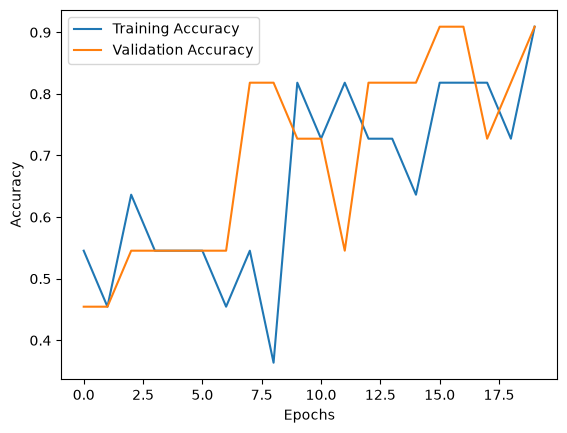

In [19]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Class names: ['cavity_tooth', 'normal_tooth']


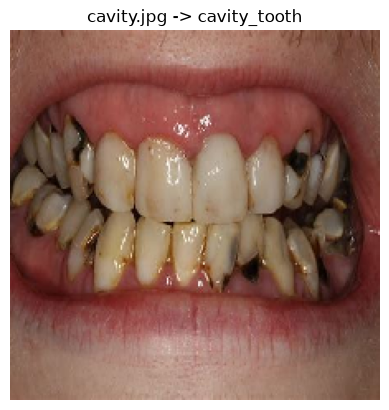

Raw prediction: 0.05131723
Predicted: cavity_tooth
--------------------------------------------------


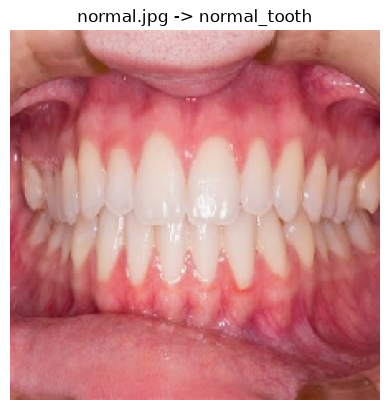

Raw prediction: 0.60791504
Predicted: normal_tooth
--------------------------------------------------


In [20]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

test_dir = "Base data/test"

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".avif")

class_names = list(train_dataset.class_indices.keys())
print("Class names:", class_names)

for root, dirs, files in os.walk("Base data/test"):
    for filename in files:
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(root, filename)

            img = image.load_img(img_path, target_size=(224, 224))
            X = image.img_to_array(img)
            X = np.expand_dims(X, axis=0) / 255.0

            prediction = model.predict(X, verbose=0)[0][0]

            predicted_class = class_names[1] if prediction >= 0.5 else class_names[0]

            plt.imshow(img)
            plt.title(f"{filename} -> {predicted_class}")
            plt.axis("off")
            plt.show()

            print("Raw prediction:", prediction)
            print("Predicted:", predicted_class)
            print("-" * 50)